In [5]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.naive_bayes import MultinomialNB
import string
from nltk.corpus import stopwords
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp

# Load the data

In [ ]:
## Read Data
df = pd.read_csv("dataset/training_data.csv", sep="\t", header=None, names=["label", "text"])

In [ ]:
# Coppying data:
data = df.copy()

# Inspect the data

In [ ]:
# Inspect the data
data.head()

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [ ]:
data.tail()

,label,text
34147,1,tears in rain as thais gather for late king's ...
34148,1,pyongyang university needs non-u.s. teachers a...
34149,1,philippine president duterte to visit japan ah...
34150,1,japan's abe may have won election\tbut many do...
34151,1,demoralized and divided: inside catalonia's po...


It seems the rows are grouped by label.

In [ ]:
data.shape

(34152, 2)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34152 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   34152 non-null  int64 
 1   text    34152 non-null  object
dtypes: int64(1), object(1)
memory usage: 533.8+ KB


The dataset is composed by 34152 rows and 2 columns. The label column contains only integers (0 and 1) and the text column is of object type.

In [ ]:
data.isna().sum()

label    0
text     0
dtype: int64

In [ ]:
data.duplicated().sum()

np.int64(1946)

In [ ]:
data['text'].duplicated().sum()

np.int64(1946)

There are no rows with missing information and there are 1946 duplicated entries, which should be removed.

# Pre-process the data

In [ ]:
# Remove duplicates
data_clean = data.drop_duplicates()

print(f"Original shape: {data.shape}")
print(f"Clean data shape: {data_clean.shape}")

Original shape: (34152, 2)
Clean data shape: (32206, 2)


In [ ]:
data_clean.duplicated().sum()

np.int64(0)

## Clean the text

In [28]:
# Create a function to clean the text 
def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text) # Remove special characters
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text) # Remove all single characters
    text = re.sub(r"\^[a-zA-Z]\s+", " ", text) # Remove single characters from the start
    text = re.sub(r"\s+", " ", text) # Substitute multiple spaces with a single space
    text = text.lower() # Convert to lowercase

    return text

Numbers were not removed considering they might give context to the model.

In [ ]:
data_clean['text_clean'] = data_clean['text'].apply(clean_text)
data_clean.head()

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_20681/65238994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['text_clean'] = data_clean['text'].apply(clean_text)


,label,text,text_clean
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year e...
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...,trump is so obsessed he even has obama name co...
4,0,pope francis just called out donald trump duri...,pope francis just called out donald trump duri...


## Remove stopwords

In [27]:
# Create a function to remove stopwords
def remove_stopwords(text):
    processed_docs = []
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)

    for word in tokens:
        if word not in stop_words:
            processed_docs.append(word)
    return ' '.join(processed_docs)

In [ ]:
data_clean['text_no_stopwords'] = data_clean['text_clean'].apply(remove_stopwords)
data_clean.head()

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_20681/4167281436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['text_no_stopwords'] = data_clean['text_clean'].apply(remove_stopwords)


,label,text,text_clean,text_no_stopwords
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year e...,donald trump sends embarrassing new year eve m...
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes internet joke thr...
3,0,trump is so obsessed he even has obama‚s name ...,trump is so obsessed he even has obama name co...,trump obsessed even obama name coded website i...
4,0,pope francis just called out donald trump duri...,pope francis just called out donald trump duri...,pope francis called donald trump christmas speech


## Lemmatization

In [29]:
def get_wordnet_pos(text):
    tag = nltk.pos_tag([text])[0][1][0]
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    
    return tag_dict.get(tag, wordnet.NOUN)

In [30]:
wordnet_lemma  = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmatized = [wordnet_lemma.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return ' '.join(lemmatized)

In [ ]:
data_clean['text_lemmatized'] = data_clean['text_no_stopwords'].apply(lemmatize_text)
data_clean.head()

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_20681/2181263826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['text_lemmatized'] = data_clean['text_no_stopwords'].apply(lemmatize_text)


,label,text,text_clean,text_no_stopwords,text_lemmatized
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year e...,donald trump sends embarrassing new year eve m...,donald trump sends embarrassing new year eve m...
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes internet joke thr...,sheriff david clarke becomes internet joke thr...
3,0,trump is so obsessed he even has obama‚s name ...,trump is so obsessed he even has obama name co...,trump obsessed even obama name coded website i...,trump obsessed even obama name coded website i...
4,0,pope francis just called out donald trump duri...,pope francis just called out donald trump duri...,pope francis called donald trump christmas speech,pope francis called donald trump christmas speech


In [ ]:
# Evaluate is the preprocessing led to empty rows
data_clean[data_clean['text_lemmatized'].str.strip() == ""]

,label,text,text_clean,text_no_stopwords,text_lemmatized
986,0,no,no,,
1708,0,once again,once again,,
8891,0,so,so,,


In [ ]:
data_clean_final = data_clean[data_clean["text_lemmatized"].str.strip() != ""].reset_index(drop=True)

display(data_clean_final.head())
print(f"Final shape {data_clean_final.shape}")

,label,text,text_clean,text_no_stopwords,text_lemmatized
0,0,donald trump sends out embarrassing new year‚s...,donald trump sends out embarrassing new year e...,donald trump sends embarrassing new year eve m...,donald trump sends embarrassing new year eve m...
1,0,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes an internet joke ...,sheriff david clarke becomes internet joke thr...,sheriff david clarke becomes internet joke thr...
3,0,trump is so obsessed he even has obama‚s name ...,trump is so obsessed he even has obama name co...,trump obsessed even obama name coded website i...,trump obsessed even obama name coded website i...
4,0,pope francis just called out donald trump duri...,pope francis just called out donald trump duri...,pope francis called donald trump christmas speech,pope francis called donald trump christmas speech


Final shape (32203, 5)


In [ ]:
data_clean_final.to_csv("dataset/cleaned_training_data.csv", index=False)

## Split the dataset

In [ ]:
# Split into features and labels

X = data_clean['text_lemmatized']
y = data_clean['label']
print(X)
print(y)

0        donald trump sends embarrassing new year eve m...
1        drunk bragging trump staffer started russian c...
2        sheriff david clarke becomes internet joke thr...
3        trump obsessed even obama name coded website i...
4        pope francis called donald trump christmas speech
                               ...                        
34147              tear rain thai gather late king funeral
34148    pyongyang university need non teacher travel b...
34149    philippine president duterte visit japan ahead...
34150                  japan abe may election many want pm
34151    demoralized divided inside catalonia police force
Name: text_lemmatized, Length: 32206, dtype: object
0        0
1        0
2        0
3        0
4        0
        ..
34147    1
34148    1
34149    1
34150    1
34151    1
Name: label, Length: 32206, dtype: int64


In [ ]:
# Split data into training and testing set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X original shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(f"y original shape: {y.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X original shape: (32206,)
X_train shape: (25764,)
X_test shape: (6442,)
y original shape: (32206,)
y_train shape: (25764,)
y_test shape: (6442,)


## Bag of Words

In [ ]:
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Feature names:", vectorizer.get_feature_names_out())
print("Matrix shape:", X_train_bow.shape)
print("Matrix type:", type(X_train_bow))
print("Document-Term Matrix:\n", X_train_bow.toarray())

Vocabulary size: 14837
Feature names: ['00' '0045' '0111' ... 'zuma' 'zummar' 'zurich']
Matrix shape: (25764, 14837)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Document-Term Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
# L2 (Euclidean) vector normalization

from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm="l2")

X_train_bow_normalized = normalizer.fit_transform(X_train_bow)
X_test_bow_normalized = normalizer.transform(X_test_bow)

print(X_train_bow)
print(X_train_bow_normalized)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 221820 stored elements and shape (25764, 14837)>
  Coords	Values
  (0, 7226)	1
  (0, 10505)	1
  (0, 7182)	1
  (0, 1768)	1
  (0, 5880)	1
  (0, 1145)	1
  (1, 2912)	1
  (1, 13467)	1
  (1, 2724)	2
  (1, 9998)	1
  (1, 5697)	1
  (1, 12140)	1
  (2, 7583)	1
  (2, 3284)	1
  (2, 4593)	1
  (2, 7126)	1
  (2, 3780)	1
  (2, 11443)	1
  (3, 13294)	1
  (3, 4251)	1
  (3, 634)	1
  (3, 12112)	1
  (3, 9684)	1
  (3, 14428)	1
  (3, 5920)	1
  :	:
  (25761, 9091)	1
  (25761, 458)	1
  (25761, 3911)	1
  (25761, 14348)	1
  (25761, 7577)	1
  (25761, 12798)	1
  (25761, 10320)	1
  (25761, 12693)	1
  (25761, 9600)	1
  (25762, 14213)	1
  (25762, 2668)	1
  (25762, 11444)	2
  (25762, 10894)	1
  (25762, 13041)	1
  (25762, 7206)	1
  (25762, 7312)	1
  (25762, 11083)	1
  (25762, 4336)	1
  (25762, 4139)	1
  (25763, 9170)	1
  (25763, 2734)	1
  (25763, 2240)	1
  (25763, 13697)	1
  (25763, 3048)	1
  (25763, 5482)	1
<Compressed Sparse Row sparse matrix of dtype 'float64

## TF-IDF

In [ ]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Print the shape of the dataset
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape: ", X_test_tfidf.shape)

X_train_tfidf shape: (25764, 14837)
X_test_tfidf shape:  (6442, 14837)


## Baseline classifiers

For this project, the following classifiers will be used:

* Random Forest Classifier
* XGBoost Classifier
* MultinomialNB Classifier

### Random Forest Classifier

In [ ]:
# Bag of Words
rf_bow = RandomForestClassifier(criterion='entropy')

rf_bow.fit(X_train_bow_normalized, y_train)

y_pred_rf_bow = rf_bow.predict(X_test_bow_normalized)

print("RandomForest Classifier with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_bow))
print(classification_report(y_test, y_pred_rf_bow))
print(confusion_matrix(y_test, y_pred_rf_bow))

# Bag of Words
rf_tfidf = RandomForestClassifier(criterion='entropy')

rf_tfidf.fit(X_train_tfidf, y_train)

y_pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)

print("RandomForest Classifier with TF-IDF")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tfidf))
print(classification_report(y_test, y_pred_rf_tfidf))
print(confusion_matrix(y_test, y_pred_rf_tfidf))

RandomForest Classifier with CountVectorizer
Accuracy: 0.9126047811238746
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      3233
           1       0.91      0.92      0.91      3209

    accuracy                           0.91      6442
   macro avg       0.91      0.91      0.91      6442
weighted avg       0.91      0.91      0.91      6442

[[2934  299]
 [ 264 2945]]
RandomForest Classifier with TF-IDF
Accuracy: 0.9098106178205526
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      3233
           1       0.91      0.91      0.91      3209

    accuracy                           0.91      6442
   macro avg       0.91      0.91      0.91      6442
weighted avg       0.91      0.91      0.91      6442

[[2945  288]
 [ 293 2916]]


### MultinomialNB

In [ ]:
# Bag of Words

nb_count_bow = MultinomialNB()

nb_count_bow.fit(X_train_bow_normalized, y_train) 

y_pred_nb_count_bow = nb_count_bow.predict(X_test_bow_normalized)

print("MultinomialNB with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_count_bow))
print(classification_report(y_test, y_pred_nb_count_bow))
print(confusion_matrix(y_test, y_pred_nb_count_bow))

# TF-IDF 

nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf, y_train)

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("MultinomialNB with TF-IDF")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_tfidf))
print(classification_report(y_test, y_pred_nb_tfidf))
print(confusion_matrix(y_test, y_pred_nb_tfidf))

MultinomialNB with CountVectorizer
Accuracy: 0.9276622167028873
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      3233
           1       0.93      0.92      0.93      3209

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[3014  219]
 [ 247 2962]]
MultinomialNB with TF-IDF
Accuracy: 0.9265755976404844
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      3233
           1       0.93      0.92      0.93      3209

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[3019  214]
 [ 259 2950]]


### XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# Bag of Words
xgb_bow = XGBClassifier(eval_metric="logloss")

xgb_bow.fit(X_train_bow_normalized, y_train)

y_pred_xgb_bow = xgb_bow.predict(X_test_bow_normalized)

print("XGBoost with CountVectorizer")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_bow))
print(classification_report(y_test, y_pred_xgb_bow))
print(confusion_matrix(y_test, y_pred_xgb_bow))

# TF-IDF
xgb_tfidf = XGBClassifier(eval_metric="logloss")

xgb_tfidf.fit(X_train_tfidf, y_train)

y_pred_xgb_tfidf = xgb_tfidf.predict(X_test_tfidf)

print("XGBoost with TF-IDF")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tfidf))
print(classification_report(y_test, y_pred_xgb_tfidf))
print(confusion_matrix(y_test, y_pred_xgb_tfidf))

XGBoost with CountVectorizer
Accuracy: 0.888854393045638
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      3233
           1       0.85      0.94      0.89      3209

    accuracy                           0.89      6442
   macro avg       0.89      0.89      0.89      6442
weighted avg       0.89      0.89      0.89      6442

[[2706  527]
 [ 189 3020]]
XGBoost with TF-IDF
Accuracy: 0.8793852840732692
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      3233
           1       0.84      0.94      0.89      3209

    accuracy                           0.88      6442
   macro avg       0.88      0.88      0.88      6442
weighted avg       0.88      0.88      0.88      6442

[[2659  574]
 [ 203 3006]]


In all models, the bag of words vectorizing achieved a higher accuracy, which was more proeminent on XGBoost.

Considering this, the optimization of the classifiers will use CountVectorizer instead of TF-IDF.

## MultinomialNB Optimisation from Cleaned Data

Uploading the cleaned training CSV data, by using the lemmatised text as input.

In [6]:
data = pd.read_csv("cleaned_training_data.csv")

X = data["text_lemmatized"]
y = data["label"]

Splitting the data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(25762,) (6441,)
label
1    0.502484
0    0.497516
Name: proportion, dtype: float64
label
1    0.502406
0    0.497594
Name: proportion, dtype: float64


The split is balanced, meaning that stratify=y worked correctly.

## Tuning of CountVectorizer parameters

Testing various CountVectorizer (Bag-of-Words) settings and ranking them by f1_macro for the MultinomialNB model.

This is in order to investigate which Bag-of-Words representation gives MultinomialNB the best validation result.

**Note:** The F1_macro allows for the calculation of the F1-score separately for each class, then take the simple average.

In [8]:
vectorizer_experiments = [
    {"ngram_range": (1, 1), "max_df": 1.0, "min_df": 1, "max_features": None},
    {"ngram_range": (1, 2), "max_df": 1.0, "min_df": 1, "max_features": None},
    {"ngram_range": (1, 2), "max_df": 0.95, "min_df": 2, "max_features": None},
    {"ngram_range": (1, 2), "max_df": 0.90, "min_df": 2, "max_features": 20000},
    {"ngram_range": (1, 3), "max_df": 0.95, "min_df": 2, "max_features": 30000},
]

results = []

for params in vectorizer_experiments:
    vectorizer = CountVectorizer(**params)
    
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    
    y_pred = model.predict(X_test_vec)
    
    results.append({
        "vectorizer": "CountVectorizer",
        "params": params,
        "vocab_size": len(vectorizer.vocabulary_),
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="f1_macro", ascending=False)

,vectorizer,params,vocab_size,accuracy,f1_macro,f1_weighted
1,CountVectorizer,"{'ngram_range': (1, 2), 'max_df': 1.0, 'min_df...",150868,0.933395,0.933394,0.933396
4,CountVectorizer,"{'ngram_range': (1, 3), 'max_df': 0.95, 'min_d...",30000,0.929825,0.929824,0.929825
2,CountVectorizer,"{'ngram_range': (1, 2), 'max_df': 0.95, 'min_d...",29059,0.929048,0.929046,0.929048
3,CountVectorizer,"{'ngram_range': (1, 2), 'max_df': 0.9, 'min_df...",20000,0.928738,0.928735,0.928737
0,CountVectorizer,"{'ngram_range': (1, 1), 'max_df': 1.0, 'min_df...",14968,0.925322,0.925318,0.925320


The best result was:

ngram_range=(1,2), max_df=1.0, min_df=1, max_features=None
accuracy = 0.933395
f1_macro = 0.933394
vocab_size = 150,868

Insights:

- It uses unigrams and bigrams.
- It keeps all words/phrases, including rare ones.
- It created a very large vocabulary: 150,868 features.
- It achieved approximately 93.34% validation accuracy/F1.

Conclusions:

1. Bigrams helped given that:

    - (1,1) - unigrams - only resulted in 0.9253 whereas (1,2) - unigrams and bigrams - resulted in 0.9334.

    - So adding two-word phrases improved performance.

    - That supports the conclusion that short expressions in headlines are useful.

2. Removing rare/common words slightly reduced performance

    - The best model kept everything:

        - max_df=1.0
        - min_df=1
        - max_features=None

    - When restricting features with min_df=2, max_df=0.95, or max_features, performance dropped slightly.

    - So for MultinomialNB, one concludes that rare words/bigrams may still be useful in this dataset.

3. Trigrams did not yield better results compared to bigrams, given that(1,3) with max_features=30000 resulted in 0.9298.

    - This is a good result, but not better than (1,2) unrestricted.

    - So trigrams are not the best approach in this case.

4. Accuracy, F1 macro, and F1 weighted are almost identical

    - This means the classes are balanced and the model performs similarly on both fake and real, which is a good indicator.

Continuing with the winning CountVectorizer setup from the previous step, by rebuilding the best Bag-of-Words representation: unigrams and bigrams, with no feature restriction.

- X_train_best corresponds to the training headlines converted into numerical Bag-of-Words features using the best vectorizer.

- X_test_best represents validation headlines converted using the same fitted vectorizer.

- By “best” we refer to the CountVectorizer settings that yielded the best result: ngram_range=(1,2), max_df=1.0, min_df=1, max_features=None.

In [9]:
best_vectorizer_params = {
    "ngram_range": (1, 2),
    "max_df": 1.0,
    "min_df": 1,
    "max_features": None
}

best_count_vectorizer = CountVectorizer(**best_vectorizer_params)

X_train_best = best_count_vectorizer.fit_transform(X_train)
X_test_best = best_count_vectorizer.transform(X_test)

print(X_train_best.shape)
print(X_test_best.shape)

(25762, 150868)
(6441, 150868)


## MultinomialNB Hyperparameter Tuning

Testing several alpha values and both fit_prior=True/False.

The results are ranked by f1_macro.

In [10]:
alpha_values = [
    0.0001, 0.0005,
    0.001, 0.005,
    0.01, 0.05,
    0.1, 0.3, 0.5, 0.8,
    1.0, 1.5, 2.0, 3.0, 5.0, 10.0
]

fit_prior_values = [True, False]

nb_results = []

for alpha in alpha_values:
    for fit_prior in fit_prior_values:
        
        model = MultinomialNB(
            alpha=alpha,
            fit_prior=fit_prior
        )
        
        model.fit(X_train_best, y_train)
        y_pred = model.predict(X_test_best)
        
        nb_results.append({
            "alpha": alpha,
            "fit_prior": fit_prior,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted")
        })

nb_results_df = pd.DataFrame(nb_results)

nb_results_df.sort_values(by="f1_macro", ascending=False)

,alpha,fit_prior,accuracy,f1_macro,f1_weighted
16,0.5000,True,0.935724,0.935722,0.935724
17,0.5000,False,0.935259,0.935257,0.935258
14,0.3000,True,0.935259,0.935256,0.935258
15,0.3000,False,0.935103,0.935101,0.935103
19,0.8000,False,0.934172,0.934170,0.934172
13,0.1000,False,0.934172,0.934169,0.934171
12,0.1000,True,0.934172,0.934169,0.934171
18,0.8000,True,0.933861,0.933859,0.933861
20,1.0000,True,0.933395,0.933394,0.933396
21,1.0000,False,0.933240,0.933239,0.933240


The best result was:

- alpha = 0.5
- fit_prior = True
- accuracy = 0.935724
- f1_macro = 0.935722
- f1_weighted = 0.935724

The best MultinomialNB setup correctly predicts about 93.57% of validation headlines.

## Interpretation

After selecting the best CountVectorizer configuration, we tuned the MultinomialNB classifier itself.

The parameters tested were:

- `alpha`: smoothing parameter used by MultinomialNB.
- `fit_prior`: whether the model learns the class prior probabilities from the training data.

### What `alpha` does

`alpha` controls smoothing.

In simple terms, smoothing prevents the model from becoming too confident when a word or bigram appears strongly in one class but rarely or never in the other.

- Very small `alpha` values make the model more sensitive to rare words and bigrams.
- Larger `alpha` values smooth the probabilities more strongly.
- The default value is `alpha = 1.0`.

### What `fit_prior` does

`fit_prior` controls whether the model learns how common each class is in the training data.

- `fit_prior=True`: the model learns the class balance from the training data.
- `fit_prior=False`: the model treats both classes as equally likely before looking at the words.

Since the dataset is almost balanced between fake and real news, the effect of `fit_prior` is expected to be small.

---

## Best Result

The best-performing configuration was:

- `alpha = 0.5`
- `fit_prior = True`

Performance:

- Accuracy: `0.935724`
- F1 macro: `0.935722`
- F1 weighted: `0.935724`

This means that the tuned MultinomialNB model correctly classified approximately **93.57%** of the validation headlines.

---

## Main Observations

### 1. Tuning improved the model

The default MultinomialNB setting is usually:

- `alpha = 1.0`
- `fit_prior = True`

With the default setup, the model achieved:

- Accuracy: `0.933395`
- F1 macro: `0.933394`

After tuning, the best setup achieved:

- Accuracy: `0.935724`
- F1 macro: `0.935722`

So tuning `alpha` improved the model slightly.

---

### 2. `alpha = 0.5` gave the best balance

The best result came from `alpha = 0.5`.

This suggests that the model benefited from some smoothing, but not as much as the default `alpha = 1.0`.

In this dataset, reducing smoothing slightly helped the model use word and bigram patterns more effectively.

---

### 3. Very small `alpha` values performed worse

Very small values such as:

- `alpha = 0.0001`
- `alpha = 0.0005`
- `alpha = 0.001`

performed worse than the best result.

This suggests that if smoothing is too weak, the model becomes too sensitive to rare words or rare bigrams. That can hurt generalisation on unseen validation data.

---

### 4. Very large `alpha` values also performed worse

Larger values such as:

- `alpha = 5.0`
- `alpha = 10.0`

also performed worse.

This suggests that too much smoothing makes the model less sensitive to useful differences between fake and real headlines.

In other words, excessive smoothing weakens important word-level signals.

---

### 5. `fit_prior=True` was slightly better

The best result used:

- `fit_prior=True`

This means the model used the class proportions learned from the training data.

However, the difference between `fit_prior=True` and `fit_prior=False` was small because the dataset is almost balanced between fake and real news.

---

### 6. Accuracy, F1 macro, and F1 weighted are very close

The accuracy, F1 macro, and F1 weighted scores are almost identical.

This is a good indicator because it suggests:

- the dataset is balanced;
- the model is not only performing well on one class;
- fake and real news are being handled in a relatively balanced way.

---

## Conclusion

The best MultinomialNB configuration found was:

- CountVectorizer with unigrams and bigrams;
- `alpha = 0.5`;
- `fit_prior = True`.

This configuration achieved the best validation performance for the MultinomialNB branch.

The next step is to automatically select these best parameters from the results table, retrain the final MultinomialNB candidate model, and evaluate it with a classification report and confusion matrix.

We will now pick the best parameters automatically.

In [11]:
best_nb_row = nb_results_df.sort_values(by="f1_macro", ascending=False).iloc[0]

best_alpha = best_nb_row["alpha"]
best_fit_prior = best_nb_row["fit_prior"]

print("Best alpha:", best_alpha)
print("Best fit_prior:", best_fit_prior)
print("Best f1_macro:", best_nb_row["f1_macro"])
print("Best accuracy:", best_nb_row["accuracy"])

Best alpha: 0.5
Best fit_prior: True
Best f1_macro: 0.9357221453325231
Best accuracy: 0.935724266418258


Training the final MultinomialNB candidate model by using the best numerical representation of the training text, as determined in previous steps.

In [12]:
final_nb = MultinomialNB(
    alpha=best_alpha,
    fit_prior=best_fit_prior
)

final_nb.fit(X_train_best, y_train)

y_pred_final = final_nb.predict(X_test_best)

## Final Model Evaluation

In [14]:
print("Final MultinomialNB with CountVectorizer")
print("Best vectorizer params:", best_vectorizer_params)
print("Best alpha:", best_alpha)
print("Best fit_prior:", best_fit_prior)

print("\nAccuracy:", accuracy_score(y_test, y_pred_final))

print("\nClassification report:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final MultinomialNB with CountVectorizer
Best vectorizer params: {'ngram_range': (1, 2), 'max_df': 1.0, 'min_df': 1, 'max_features': None}
Best alpha: 0.5
Best fit_prior: True

Accuracy: 0.935724266418258

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      3205
           1       0.94      0.94      0.94      3236

    accuracy                           0.94      6441
   macro avg       0.94      0.94      0.94      6441
weighted avg       0.94      0.94      0.94      6441


Confusion matrix:
[[2995  210]
 [ 204 3032]]


## Final Evaluation (MultinomialNB with CountVectorizer)

The final MultinomialNB model used the best CountVectorizer settings found during tuning:

- `ngram_range = (1, 2)`
- `max_df = 1.0`
- `min_df = 1`
- `max_features = None`

The best MultinomialNB parameters were:

- `alpha = 0.5`
- `fit_prior = True`

The final validation accuracy was:

- `0.9357`, or approximately **93.57%**

This means the model correctly classified around 93.6% of the validation headlines.

The classification report shows balanced performance across both classes:

- Class `0` = fake news
- Class `1` = real news

Both classes achieved approximately:

- Precision: `0.94`
- Recall: `0.93–0.94`
- F1-score: `0.94`

This is a strong result because the model is not only performing well overall, but also performing similarly for fake and real news.

The macro average and weighted average are also very close. This confirms that the model is balanced and that the dataset split has similar numbers of fake and real headlines.

## Confusion matrix heatmap

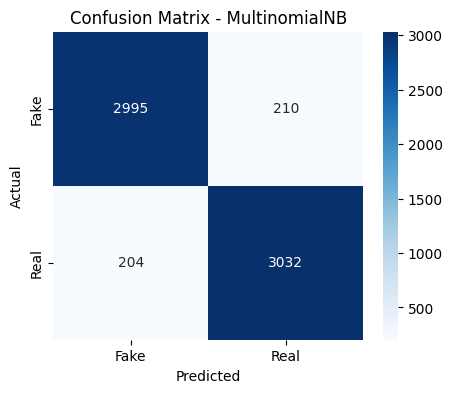

In [16]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MultinomialNB")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows how many predictions were correct and incorrect for each class.

The matrix was:

| Actual / Predicted | Predicted Fake | Predicted Real |
|---|---:|---:|
| Actual Fake | 2995 | 210 |
| Actual Real | 204 | 3032 |

Interpretation:

- `2995` fake headlines were correctly predicted as fake.
- `3032` real headlines were correctly predicted as real.
- `210` fake headlines were incorrectly predicted as real.
- `204` real headlines were incorrectly predicted as fake.

This shows that the model makes a similar number of mistakes in both directions.

There is no strong bias toward predicting only one class. The model is balanced and performs well on both fake and real news.

Overall, the confusion matrix supports the classification report: the final MultinomialNB model is accurate, balanced, and reliable for this validation split.

# Final Prediction on Testing Data

We now load the best saved model, preprocess the testing data in the same way as the training data, predict labels, replace label `2`, and save the final CSV.

Loading the final chosen model and vectoriser selected after comparing all team members' results.

In [17]:
import joblib

joblib.dump(final_nb, "best_multinomialnb_model.joblib")
joblib.dump(best_count_vectorizer, "best_count_vectorizer.joblib")

['best_count_vectorizer.joblib']

In [19]:
best_vectorizer = joblib.load("best_count_vectorizer.joblib")
best_model = joblib.load("best_multinomialnb_model.joblib")

Loading the testing dataset. The label column currently contains placeholder value `2`.

In [34]:
test_df = pd.read_csv(
    '../dataset/testing_data.csv',
    sep='\t', header=None, names=['label', 'text'])

print(test_df.head())
print(test_df.shape)
print(test_df.columns)

  label                                               text
0     2  copycat muslim terrorist arrested with assault...
1     2  wow! chicago protester caught on camera admits...
2     2   germany's fdp look to fill schaeuble's big shoes
3     2  mi school sends welcome back packet warning ki...
4     2  u.n. seeks 'massive' aid boost amid rohingya '...
(9984, 2)
Index(['label', 'text'], dtype='str')


We apply the same preprocessing used for the training data: 
- cleaning;
- stop-word removal;
- lemmatisation. 

In [35]:
test_df.duplicated().sum()

np.int64(775)

In [36]:
# Removing duplicates
test_df_clean = test_df.drop_duplicates()

print(f"Original shape: {test_df.shape}")
print(f"Clean data shape: {test_df_clean.shape}")

Original shape: (9984, 2)
Clean data shape: (9209, 2)


In [37]:
test_df_clean.duplicated().sum()

np.int64(0)

In [ ]:
test_df_clean["text_clean"] = test_df_clean["text"].apply(clean_text)
test_df_clean["text_no_stopwords"] = test_df_clean["text_clean"].apply(remove_stopwords)
test_df_clean["text_lemmatized"] = test_df_clean["text_no_stopwords"].apply(lemmatize_text)   

In [40]:
test_df_clean.head()

,label,text,text_clean,text_no_stopwords,text_lemmatized
0,2,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested assault weapons,copycat muslim terrorist arrested assault weapon
1,2,wow! chicago protester caught on camera admits...,wow chicago protester caught on camera admits ...,wow chicago protester caught camera admits vio...,wow chicago protester caught camera admits vio...
2,2,germany's fdp look to fill schaeuble's big shoes,germany fdp look to fill schaeuble big shoes,germany fdp look fill schaeuble big shoes,germany fdp look fill schaeuble big shoe
3,2,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...,u seeks massive aid boost amid rohingya emerge...,u seeks massive aid boost amid rohingya emerge...,u seek massive aid boost amid rohingya emergen...


In [41]:
test_df_clean[test_df_clean['text_lemmatized'].str.strip() == ""]

,label,text,text_clean,text_no_stopwords,text_lemmatized


In [ ]:
'''
test_df_final = test_df[test_df["text_lemmatized"].str.strip() != ""].reset_index(drop=True)

display(test_df_final.head())
print(f"Final shape {test_df_final.shape}")

'''

In [42]:
test_df_clean.to_csv("../dataset/cleaned_testing_data.csv", index=False)

Converting the cleaned testing text into numerical features using the already-fitted vectoriser.

In [43]:
X_testing_vec = best_vectorizer.transform(test_df_clean["text_lemmatized"])

Performing normalisation:

In [45]:
# L2 (Euclidean) vector normalization

from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm="l2")

X_testing_vec_normalized = normalizer.transform(X_testing_vec)

print(X_testing_vec_normalized)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 123230 stored elements and shape (9209, 150868)>
  Coords	Values
  (0, 8555)	0.30151134457776363
  (0, 8563)	0.30151134457776363
  (0, 9229)	0.30151134457776363
  (0, 9274)	0.30151134457776363
  (0, 30228)	0.30151134457776363
  (0, 30230)	0.30151134457776363
  (0, 85840)	0.30151134457776363
  (0, 85998)	0.30151134457776363
  (0, 131962)	0.30151134457776363
  (0, 131970)	0.30151134457776363
  (0, 146546)	0.30151134457776363
  (1, 2817)	0.2
  (1, 2821)	0.2
  (1, 3410)	0.2
  (1, 3469)	0.2
  (1, 19898)	0.2
  (1, 19900)	0.2
  (1, 21532)	0.2
  (1, 21539)	0.2
  (1, 23131)	0.2
  (1, 23160)	0.2
  (1, 55800)	0.2
  (1, 55801)	0.2
  (1, 86216)	0.2
  (1, 86230)	0.2
  :	:
  (9208, 20925)	0.1796053020267749
  (9208, 20928)	0.1796053020267749
  (9208, 33512)	0.1796053020267749
  (9208, 33523)	0.1796053020267749
  (9208, 38842)	0.1796053020267749
  (9208, 38904)	0.1796053020267749
  (9208, 61588)	0.1796053020267749
  (9208, 61589)	0.17960530

Predicting labels; the saved model will now predict whether each headline is fake (`0`) or real (`1`).

In [46]:
test_predictions = best_model.predict(X_testing_vec_normalized)

print(pd.Series(test_predictions).value_counts())

1    4889
0    4320
Name: count, dtype: int64


We will now replace the placeholder label `2` with the predicted labels `0` or `1`, while keeping the original file structure.

In [48]:
final_submission = test_df_clean.copy()
final_submission["label"] = test_predictions

print(final_submission["label"].unique())
display(final_submission.head())

[0 1]


,label,text,text_clean,text_no_stopwords,text_lemmatized
0,0,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested assault weapons,copycat muslim terrorist arrested assault weapon
1,0,wow! chicago protester caught on camera admits...,wow chicago protester caught on camera admits ...,wow chicago protester caught camera admits vio...,wow chicago protester caught camera admits vio...
2,1,germany's fdp look to fill schaeuble's big shoes,germany fdp look to fill schaeuble big shoes,germany fdp look fill schaeuble big shoes,germany fdp look fill schaeuble big shoe
3,0,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...,u seeks massive aid boost amid rohingya emerge...,u seeks massive aid boost amid rohingya emerge...,u seek massive aid boost amid rohingya emergen...


Saving the final predictions file in CSV format with no extra columns.

In [49]:
final_submission.to_csv("testing_data_predictions.csv", index=False)